# Advanced Solution: Immutable Regular Polygons and Polygon Sequences

This notebook implements an assignment-ready, production-minded solution for a finite sequence of regular convex polygons.

Added-value features beyond the minimum requirements:

- immutable `Polygon` and `Polygons` objects
- strict input validation
- rich polygon geometry properties
- polygon vertex coordinate generation
- bounding box calculation
- SVG generation for lightweight visualization
- optional Matplotlib plotting helpers
- dictionary / JSON-style serialization
- fully featured indexing, negative indexing, slicing, and extended slicing
- iteration and reversed iteration
- membership checks
- utility methods for summaries, filtering, ranking, and lookup by vertex count
- comprehensive unit tests


## Mathematical formulas

For a regular convex polygon with `n` vertices and circumradius `R`:

- edge length: `s = 2R sin(pi / n)`
- apothem: `a = R cos(pi / n)`
- perimeter: `P = ns`
- area: `A = (1/2)Pa`
- central angle in degrees: `360 / n`
- exterior angle in degrees: `360 / n`
- interior angle in degrees: `((n - 2) / n) * 180`

The `area:perimeter` ratio is:

`A / P = a / 2 = R cos(pi / n) / 2`

For a fixed circumradius, this ratio increases as the number of vertices increases. Therefore, in this finite sequence, the polygon with the highest `area:perimeter` ratio is the polygon with the largest number of vertices.


In [1]:
import json
import math
import numbers


class ValidationError(ValueError):
    """Raised when a polygon or polygon-sequence argument is invalid."""


def validate_positive_finite_real(value, name):
    """Return value as float after validating it is a positive finite real number."""
    if isinstance(value, bool) or not isinstance(value, numbers.Real):
        raise TypeError("{0} must be a real number".format(name))

    value = float(value)

    if not math.isfinite(value):
        raise ValidationError("{0} must be finite".format(name))

    if value <= 0:
        raise ValidationError("{0} must be greater than 0".format(name))

    return value


def validate_int_at_least(value, minimum, name):
    """Validate that value is an integer greater than or equal to minimum."""
    if isinstance(value, bool) or not isinstance(value, int):
        raise TypeError("{0} must be an integer".format(name))

    if value < minimum:
        raise ValidationError("{0} must be at least {1}".format(name, minimum))

    return value


def round_tuple(values, ndigits=10):
    """Return a tuple whose numeric values are rounded to ndigits."""
    return tuple(round(value, ndigits) for value in values)


In [2]:
class Polygon(object):
    """
    Immutable regular convex polygon centered at (0, 0).

    Equality:
        Two polygons are equal when they have the same number of vertices
        and the same circumradius.

    Ordering:
        Polygons are ordered by number of vertices only.

    Coordinate convention:
        Vertex 0 is placed at angle 0 radians, so the first vertex is (R, 0).
        Remaining vertices proceed counter-clockwise.
    """

    __slots__ = (
        "_num_vertices",
        "_circumradius",
        "_edge_length",
        "_apothem",
        "_perimeter",
        "_area",
        "_interior_angle",
        "_central_angle",
        "_exterior_angle",
        "_vertices",
        "_bounding_box",
    )

    def __init__(self, num_vertices, circumradius):
        num_vertices = validate_int_at_least(num_vertices, 3, "num_vertices")
        circumradius = validate_positive_finite_real(circumradius, "circumradius")

        object.__setattr__(self, "_num_vertices", num_vertices)
        object.__setattr__(self, "_circumradius", circumradius)

        edge_length = 2 * circumradius * math.sin(math.pi / num_vertices)
        apothem = circumradius * math.cos(math.pi / num_vertices)
        perimeter = num_vertices * edge_length
        area = 0.5 * perimeter * apothem
        interior_angle = (num_vertices - 2) * 180 / num_vertices
        central_angle = 360 / num_vertices
        exterior_angle = 360 / num_vertices

        vertices = tuple(
            (
                circumradius * math.cos(2 * math.pi * index / num_vertices),
                circumradius * math.sin(2 * math.pi * index / num_vertices),
            )
            for index in range(num_vertices)
        )

        x_values = tuple(vertex[0] for vertex in vertices)
        y_values = tuple(vertex[1] for vertex in vertices)
        bounding_box = {
            "min_x": min(x_values),
            "max_x": max(x_values),
            "min_y": min(y_values),
            "max_y": max(y_values),
            "width": max(x_values) - min(x_values),
            "height": max(y_values) - min(y_values),
        }

        object.__setattr__(self, "_edge_length", edge_length)
        object.__setattr__(self, "_apothem", apothem)
        object.__setattr__(self, "_perimeter", perimeter)
        object.__setattr__(self, "_area", area)
        object.__setattr__(self, "_interior_angle", interior_angle)
        object.__setattr__(self, "_central_angle", central_angle)
        object.__setattr__(self, "_exterior_angle", exterior_angle)
        object.__setattr__(self, "_vertices", vertices)
        object.__setattr__(self, "_bounding_box", bounding_box)

    def __setattr__(self, name, value):
        raise AttributeError("{0} objects are immutable".format(type(self).__name__))

    def __delattr__(self, name):
        raise AttributeError("{0} objects are immutable".format(type(self).__name__))

    @property
    def num_vertices(self):
        return self._num_vertices

    @property
    def vertices_count(self):
        """Alias for num_vertices."""
        return self._num_vertices

    @property
    def vertices(self):
        """Coordinates of all vertices as an immutable tuple of (x, y) pairs."""
        return self._vertices

    @property
    def num_edges(self):
        return self._num_vertices

    @property
    def edges(self):
        """Alias for num_edges."""
        return self._num_vertices

    @property
    def circumradius(self):
        return self._circumradius

    @property
    def radius(self):
        """Alias for circumradius."""
        return self._circumradius

    @property
    def edge_length(self):
        return self._edge_length

    @property
    def side_length(self):
        """Alias for edge_length."""
        return self._edge_length

    @property
    def apothem(self):
        return self._apothem

    @property
    def inradius(self):
        """Alias for apothem."""
        return self._apothem

    @property
    def perimeter(self):
        return self._perimeter

    @property
    def area(self):
        return self._area

    @property
    def interior_angle(self):
        return self._interior_angle

    @property
    def central_angle(self):
        return self._central_angle

    @property
    def exterior_angle(self):
        return self._exterior_angle

    @property
    def area_to_perimeter_ratio(self):
        return self.area / self.perimeter

    @property
    def bounding_box(self):
        """Return a defensive copy of the polygon bounding box."""
        return dict(self._bounding_box)

    def vertex(self, index):
        """
        Return one vertex by index.

        Supports positive and negative indexing, just like a tuple.
        """
        return self.vertices[index]

    def rounded_vertices(self, ndigits=10):
        """Return vertex coordinates rounded for cleaner display or testing."""
        return tuple(round_tuple(vertex, ndigits) for vertex in self.vertices)

    def contains_vertex(self, point, rel_tol=1e-9, abs_tol=1e-9):
        """
        Return True when point is approximately one of this polygon's vertices.

        This is useful because vertex coordinates are floating-point values.
        """
        if not isinstance(point, tuple) or len(point) != 2:
            return False

        x, y = point

        if not isinstance(x, numbers.Real) or not isinstance(y, numbers.Real):
            return False

        return any(
            math.isclose(x, vertex_x, rel_tol=rel_tol, abs_tol=abs_tol)
            and math.isclose(y, vertex_y, rel_tol=rel_tol, abs_tol=abs_tol)
            for vertex_x, vertex_y in self.vertices
        )

    def scale(self, factor):
        """Return a similar polygon with circumradius multiplied by factor."""
        factor = validate_positive_finite_real(factor, "factor")
        return Polygon(self.num_vertices, self.circumradius * factor)

    def is_similar_to(self, other):
        """Regular polygons are similar when they have the same number of vertices."""
        return isinstance(other, Polygon) and self.num_vertices == other.num_vertices

    def as_dict(self, include_vertices=False):
        """
        Return a dictionary representation.

        By default this includes compact core and derived metrics.
        Pass include_vertices=True when coordinate data is needed too.
        """
        data = {
            "num_vertices": self.num_vertices,
            "num_edges": self.num_edges,
            "circumradius": self.circumradius,
            "edge_length": self.edge_length,
            "apothem": self.apothem,
            "area": self.area,
            "perimeter": self.perimeter,
            "interior_angle": self.interior_angle,
            "central_angle": self.central_angle,
            "exterior_angle": self.exterior_angle,
            "area_to_perimeter_ratio": self.area_to_perimeter_ratio,
            "bounding_box": self.bounding_box,
        }

        if include_vertices:
            data["vertices"] = self.vertices

        return data

    @classmethod
    def from_dict(cls, data):
        """Create a Polygon from a dictionary containing num_vertices and circumradius."""
        return cls(data["num_vertices"], data["circumradius"])

    def to_json(self, include_vertices=False, **json_kwargs):
        """Return a JSON string representation of the polygon."""
        return json.dumps(self.as_dict(include_vertices=include_vertices), **json_kwargs)

    def to_svg(self, size=300, padding=20, stroke_width=2):
        """
        Return a lightweight SVG string for the polygon.

        This is useful in notebooks, HTML reports, and quick visual checks.
        """
        size = validate_int_at_least(size, 1, "size")
        padding = validate_int_at_least(padding, 0, "padding")
        stroke_width = validate_positive_finite_real(stroke_width, "stroke_width")

        drawing_size = size - 2 * padding
        if drawing_size <= 0:
            raise ValidationError("size must be greater than 2 * padding")

        scale = drawing_size / (2 * self.circumradius)
        center = size / 2

        points = []
        for x, y in self.vertices:
            svg_x = center + x * scale
            svg_y = center - y * scale
            points.append("{0:.6f},{1:.6f}".format(svg_x, svg_y))

        return (
            '<svg xmlns="http://www.w3.org/2000/svg" width="{0}" height="{0}" '
            'viewBox="0 0 {0} {0}">'
            '<polygon points="{1}" fill="none" stroke="black" stroke-width="{2}"/>'
            '<circle cx="{3}" cy="{3}" r="2" fill="black"/>'
            "</svg>"
        ).format(size, " ".join(points), stroke_width, center)

    def plot(self, ax=None, show_vertices=True):
        """
        Plot the polygon with Matplotlib.

        This method is optional and only imports Matplotlib when called.
        """
        import matplotlib.pyplot as plt

        if ax is None:
            _, ax = plt.subplots()

        x_values = [point[0] for point in self.vertices] + [self.vertices[0][0]]
        y_values = [point[1] for point in self.vertices] + [self.vertices[0][1]]

        ax.plot(x_values, y_values)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(repr(self))
        ax.grid(True)

        if show_vertices:
            ax.scatter(
                [point[0] for point in self.vertices],
                [point[1] for point in self.vertices],
            )

        return ax

    def _compare_vertex_count(self, other, operator):
        if not isinstance(other, Polygon):
            return NotImplemented
        return operator(self.num_vertices, other.num_vertices)

    def __lt__(self, other):
        return self._compare_vertex_count(other, lambda left, right: left < right)

    def __le__(self, other):
        return self._compare_vertex_count(other, lambda left, right: left <= right)

    def __gt__(self, other):
        return self._compare_vertex_count(other, lambda left, right: left > right)

    def __ge__(self, other):
        return self._compare_vertex_count(other, lambda left, right: left >= right)

    def __eq__(self, other):
        if not isinstance(other, Polygon):
            return False
        return (
            self.num_vertices == other.num_vertices
            and self.circumradius == other.circumradius
        )

    def __ne__(self, other):
        return not self == other

    def __hash__(self):
        return hash((self.num_vertices, self.circumradius))

    def __repr__(self):
        return "Polygon(num_vertices={0}, circumradius={1})".format(
            self.num_vertices,
            self.circumradius,
        )


In [3]:
class Polygons(object):
    """
    Immutable finite sequence of regular convex polygons.

    The sequence contains:
        Polygon(3, R), Polygon(4, R), ..., Polygon(max_vertices, R)

    The sequence is lazy: individual Polygon instances are created only when
    requested through indexing, slicing, or iteration.
    """

    __slots__ = ("_max_vertices", "_circumradius")

    def __init__(self, max_vertices, circumradius):
        max_vertices = validate_int_at_least(max_vertices, 3, "max_vertices")
        circumradius = validate_positive_finite_real(circumradius, "circumradius")

        object.__setattr__(self, "_max_vertices", max_vertices)
        object.__setattr__(self, "_circumradius", circumradius)

    def __setattr__(self, name, value):
        raise AttributeError("{0} objects are immutable".format(type(self).__name__))

    def __delattr__(self, name):
        raise AttributeError("{0} objects are immutable".format(type(self).__name__))

    @property
    def max_vertices(self):
        return self._max_vertices

    @property
    def circumradius(self):
        return self._circumradius

    @property
    def radius(self):
        """Alias for circumradius."""
        return self._circumradius

    @property
    def length(self):
        """Convenience alias for len(self)."""
        return len(self)

    @property
    def vertex_counts(self):
        """Return all vertex counts represented by this sequence."""
        return tuple(self._vertex_range)

    @property
    def _vertex_range(self):
        return range(3, self.max_vertices + 1)

    def __len__(self):
        return self.max_vertices - 2

    def __getitem__(self, index):
        vertex_numbers = self._vertex_range

        if isinstance(index, slice):
            return tuple(
                Polygon(num_vertices, self.circumradius)
                for num_vertices in vertex_numbers[index]
            )

        if isinstance(index, int):
            try:
                num_vertices = vertex_numbers[index]
            except IndexError:
                raise IndexError("polygon index out of range")
            return Polygon(num_vertices, self.circumradius)

        raise TypeError(
            "indices must be integers or slices, not {0}".format(
                type(index).__name__
            )
        )

    def __iter__(self):
        for num_vertices in self._vertex_range:
            yield Polygon(num_vertices, self.circumradius)

    def __reversed__(self):
        for num_vertices in reversed(self._vertex_range):
            yield Polygon(num_vertices, self.circumradius)

    def __contains__(self, item):
        return (
            isinstance(item, Polygon)
            and item.circumradius == self.circumradius
            and 3 <= item.num_vertices <= self.max_vertices
        )

    @property
    def areas(self):
        return tuple(polygon.area for polygon in self)

    @property
    def perimeters(self):
        return tuple(polygon.perimeter for polygon in self)

    @property
    def area_to_perimeter_ratios(self):
        return tuple(polygon.area_to_perimeter_ratio for polygon in self)

    @property
    def max_area_perimeter_ratio_polygon(self):
        """
        Return the polygon with the highest area:perimeter ratio.

        For a fixed circumradius, this is the polygon with the largest
        number of vertices in the sequence.
        """
        return self[-1]

    @property
    def max_efficiency_polygon(self):
        """Shorter alias for max_area_perimeter_ratio_polygon."""
        return self.max_area_perimeter_ratio_polygon

    def polygon_with_vertices(self, num_vertices):
        """Return the polygon with the requested number of vertices."""
        num_vertices = validate_int_at_least(num_vertices, 3, "num_vertices")
        if num_vertices > self.max_vertices:
            raise ValidationError(
                "num_vertices must be between 3 and {0}".format(self.max_vertices)
            )
        return Polygon(num_vertices, self.circumradius)

    def index_by_vertices(self, num_vertices):
        """Return the zero-based sequence index for a given vertex count."""
        num_vertices = validate_int_at_least(num_vertices, 3, "num_vertices")
        if num_vertices > self.max_vertices:
            raise ValidationError(
                "num_vertices must be between 3 and {0}".format(self.max_vertices)
            )
        return num_vertices - 3

    def filter_by_area(self, min_area=None, max_area=None):
        """Return polygons whose area is between optional min_area and max_area limits."""
        if min_area is not None:
            min_area = validate_positive_finite_real(min_area, "min_area")

        if max_area is not None:
            max_area = validate_positive_finite_real(max_area, "max_area")

        if min_area is not None and max_area is not None and min_area > max_area:
            raise ValidationError("min_area cannot be greater than max_area")

        result = []
        for polygon in self:
            if min_area is not None and polygon.area < min_area:
                continue
            if max_area is not None and polygon.area > max_area:
                continue
            result.append(polygon)

        return tuple(result)

    def top_by_area(self, count=3, reverse=True):
        """Return the top count polygons ranked by area."""
        count = validate_int_at_least(count, 0, "count")
        return tuple(
            sorted(self, key=lambda polygon: polygon.area, reverse=reverse)[:count]
        )

    def top_by_ratio(self, count=3, reverse=True):
        """Return the top count polygons ranked by area:perimeter ratio."""
        count = validate_int_at_least(count, 0, "count")
        return tuple(
            sorted(
                self,
                key=lambda polygon: polygon.area_to_perimeter_ratio,
                reverse=reverse,
            )[:count]
        )

    def summary(self, rounded=None):
        """
        Return a tuple of dictionaries, one dictionary per polygon.

        Pass rounded=N to round numeric values to N decimal places.
        """
        rows = []

        for polygon in self:
            row = {
                "num_vertices": polygon.num_vertices,
                "circumradius": polygon.circumradius,
                "edge_length": polygon.edge_length,
                "apothem": polygon.apothem,
                "area": polygon.area,
                "perimeter": polygon.perimeter,
                "interior_angle": polygon.interior_angle,
                "area_to_perimeter_ratio": polygon.area_to_perimeter_ratio,
            }

            if rounded is not None:
                row = {
                    key: round(value, rounded) if isinstance(value, float) else value
                    for key, value in row.items()
                }

            rows.append(row)

        return tuple(rows)

    def to_table(self, rounded=6):
        """
        Return a pandas DataFrame summary.

        This is optional and only imports pandas when called.
        """
        import pandas as pd

        return pd.DataFrame(self.summary(rounded=rounded))

    def as_dict(self):
        return {
            "max_vertices": self.max_vertices,
            "circumradius": self.circumradius,
            "length": len(self),
            "vertex_counts": self.vertex_counts,
            "max_area_perimeter_ratio_polygon": self.max_area_perimeter_ratio_polygon.as_dict(),
        }

    @classmethod
    def from_dict(cls, data):
        """Create a Polygons sequence from a dictionary."""
        return cls(data["max_vertices"], data["circumradius"])

    def to_json(self, **json_kwargs):
        """Return a JSON string representation of the sequence metadata."""
        return json.dumps(self.as_dict(), **json_kwargs)

    def plot_ratios(self, ax=None):
        """
        Plot number of vertices against area:perimeter ratio.

        This method is optional and only imports Matplotlib when called.
        """
        import matplotlib.pyplot as plt

        if ax is None:
            _, ax = plt.subplots()

        ax.plot(self.vertex_counts, self.area_to_perimeter_ratios, marker="o")
        ax.set_xlabel("Number of vertices")
        ax.set_ylabel("Area : Perimeter ratio")
        ax.set_title("Polygon efficiency by vertex count")
        ax.grid(True)

        return ax

    def __repr__(self):
        return "Polygons(max_vertices={0}, circumradius={1})".format(
            self.max_vertices,
            self.circumradius,
        )


## Unit tests

The tests below cover:

- invalid inputs
- polygon formulas
- equality, hashing, and ordering
- immutability
- coordinate generation
- serialization
- SVG output
- sequence indexing and slicing
- sequence utilities


In [4]:
import unittest


class PolygonTestCase(unittest.TestCase):
    def assert_close(self, actual, expected, rel_tol=1e-12, abs_tol=1e-12):
        self.assertTrue(
            math.isclose(actual, expected, rel_tol=rel_tol, abs_tol=abs_tol),
            "Expected {0!r} to be close to {1!r}".format(actual, expected),
        )

    def test_invalid_polygon_arguments(self):
        invalid_vertices = [None, 2, 2.5, True, "3"]
        invalid_radii = [None, 0, -1, float("inf"), float("nan"), True, "1"]

        for value in invalid_vertices:
            with self.subTest(num_vertices=value):
                with self.assertRaises((TypeError, ValidationError)):
                    Polygon(value, 1)

        for value in invalid_radii:
            with self.subTest(circumradius=value):
                with self.assertRaises((TypeError, ValidationError)):
                    Polygon(3, value)

    def test_square_properties_with_unit_circumradius(self):
        polygon = Polygon(4, 1)

        self.assertEqual(polygon.num_vertices, 4)
        self.assertEqual(polygon.vertices_count, 4)
        self.assertEqual(polygon.num_edges, 4)
        self.assertEqual(polygon.edges, 4)

        self.assert_close(polygon.edge_length, math.sqrt(2))
        self.assert_close(polygon.side_length, math.sqrt(2))
        self.assert_close(polygon.apothem, math.sqrt(2) / 2)
        self.assert_close(polygon.inradius, math.sqrt(2) / 2)
        self.assert_close(polygon.perimeter, 4 * math.sqrt(2))
        self.assert_close(polygon.area, 2)
        self.assert_close(polygon.interior_angle, 90)
        self.assert_close(polygon.central_angle, 90)
        self.assert_close(polygon.exterior_angle, 90)
        self.assert_close(polygon.area_to_perimeter_ratio, polygon.apothem / 2)

    def test_triangle_properties(self):
        polygon = Polygon(3, 2)

        self.assert_close(polygon.edge_length, 2 * 2 * math.sin(math.pi / 3))
        self.assert_close(polygon.apothem, 2 * math.cos(math.pi / 3))
        self.assert_close(polygon.perimeter, 3 * polygon.edge_length)
        self.assert_close(polygon.area, 0.5 * polygon.perimeter * polygon.apothem)
        self.assert_close(polygon.interior_angle, 60)
        self.assert_close(polygon.central_angle, 120)
        self.assert_close(polygon.exterior_angle, 120)

    def test_polygon_equality_and_hashing(self):
        polygon_1 = Polygon(5, 10)
        polygon_2 = Polygon(5, 10.0)
        polygon_3 = Polygon(5, 11)
        polygon_4 = Polygon(6, 10)

        self.assertEqual(polygon_1, polygon_2)
        self.assertEqual(hash(polygon_1), hash(polygon_2))

        self.assertNotEqual(polygon_1, polygon_3)
        self.assertNotEqual(polygon_1, polygon_4)
        self.assertNotEqual(polygon_1, object())

    def test_polygon_ordering_uses_vertex_count_only(self):
        small_radius_square = Polygon(4, 1)
        large_radius_square = Polygon(4, 100)
        triangle = Polygon(3, 1000)
        pentagon = Polygon(5, 0.5)

        self.assertLess(triangle, small_radius_square)
        self.assertLess(small_radius_square, pentagon)

        self.assertLessEqual(small_radius_square, large_radius_square)
        self.assertGreaterEqual(small_radius_square, large_radius_square)

        self.assertFalse(small_radius_square < large_radius_square)
        self.assertFalse(small_radius_square > large_radius_square)
        self.assertNotEqual(small_radius_square, large_radius_square)

    def test_polygon_immutability(self):
        polygon = Polygon(4, 1)

        with self.assertRaises(AttributeError):
            polygon.num_vertices = 10

        with self.assertRaises(AttributeError):
            polygon._num_vertices = 10

        with self.assertRaises(AttributeError):
            del polygon._circumradius

    def test_vertices_and_bounding_box(self):
        polygon = Polygon(4, 1)

        expected_vertices = (
            (1.0, 0.0),
            (0.0, 1.0),
            (-1.0, 0.0),
            (-0.0, -1.0),
        )

        for actual, expected in zip(polygon.rounded_vertices(10), expected_vertices):
            self.assert_close(actual[0], expected[0])
            self.assert_close(actual[1], expected[1])

        self.assert_close(polygon.vertex(0)[0], 1.0)
        self.assert_close(polygon.vertex(-1)[1], -1.0)
        self.assertTrue(polygon.contains_vertex((1.0, 0.0)))
        self.assertFalse(polygon.contains_vertex((0.5, 0.5)))

        box = polygon.bounding_box
        self.assert_close(box["min_x"], -1.0)
        self.assert_close(box["max_x"], 1.0)
        self.assert_close(box["min_y"], -1.0)
        self.assert_close(box["max_y"], 1.0)
        self.assert_close(box["width"], 2.0)
        self.assert_close(box["height"], 2.0)

    def test_scale_and_similarity(self):
        polygon = Polygon(6, 2)
        scaled = polygon.scale(3)

        self.assertEqual(scaled, Polygon(6, 6))
        self.assertTrue(polygon.is_similar_to(scaled))
        self.assertFalse(polygon.is_similar_to(Polygon(7, 2)))

    def test_serialization(self):
        polygon = Polygon(5, 2)
        data = polygon.as_dict(include_vertices=True)

        self.assertEqual(data["num_vertices"], 5)
        self.assertEqual(data["num_edges"], 5)
        self.assertEqual(data["circumradius"], 2.0)
        self.assertIn("vertices", data)

        restored = Polygon.from_dict(data)
        self.assertEqual(restored, polygon)

        json_text = polygon.to_json()
        json_data = json.loads(json_text)
        self.assertEqual(json_data["num_vertices"], 5)
        self.assertEqual(json_data["circumradius"], 2.0)

    def test_svg_generation(self):
        polygon = Polygon(3, 1)
        svg = polygon.to_svg(size=100, padding=10)

        self.assertTrue(svg.startswith("<svg"))
        self.assertIn("<polygon", svg)
        self.assertIn("<circle", svg)

        with self.assertRaises(ValidationError):
            polygon.to_svg(size=20, padding=10)


class PolygonsSequenceTestCase(unittest.TestCase):
    def test_invalid_sequence_arguments(self):
        invalid_max_vertices = [None, 2, 3.5, False, "10"]
        invalid_radii = [None, 0, -1, float("inf"), float("nan"), False, "1"]

        for value in invalid_max_vertices:
            with self.subTest(max_vertices=value):
                with self.assertRaises((TypeError, ValidationError)):
                    Polygons(value, 1)

        for value in invalid_radii:
            with self.subTest(circumradius=value):
                with self.assertRaises((TypeError, ValidationError)):
                    Polygons(5, value)

    def test_length_and_basic_indexing(self):
        polygons = Polygons(7, 2)

        self.assertEqual(len(polygons), 5)
        self.assertEqual(polygons.length, 5)

        self.assertEqual(polygons[0], Polygon(3, 2))
        self.assertEqual(polygons[1], Polygon(4, 2))
        self.assertEqual(polygons[-1], Polygon(7, 2))
        self.assertEqual(polygons[-2], Polygon(6, 2))

        with self.assertRaises(IndexError):
            polygons[5]

        with self.assertRaises(IndexError):
            polygons[-6]

        with self.assertRaises(TypeError):
            polygons[1.5]

    def test_regular_slicing(self):
        polygons = Polygons(8, 1)

        self.assertEqual(
            polygons[0:3],
            (Polygon(3, 1), Polygon(4, 1), Polygon(5, 1)),
        )

        self.assertEqual(
            polygons[2:],
            (Polygon(5, 1), Polygon(6, 1), Polygon(7, 1), Polygon(8, 1)),
        )

        self.assertEqual(
            polygons[:2],
            (Polygon(3, 1), Polygon(4, 1)),
        )

    def test_extended_slicing(self):
        polygons = Polygons(10, 1)

        self.assertEqual(
            polygons[::2],
            (Polygon(3, 1), Polygon(5, 1), Polygon(7, 1), Polygon(9, 1)),
        )

        self.assertEqual(
            polygons[1:7:2],
            (Polygon(4, 1), Polygon(6, 1), Polygon(8, 1)),
        )

        self.assertEqual(
            polygons[::-1],
            (
                Polygon(10, 1),
                Polygon(9, 1),
                Polygon(8, 1),
                Polygon(7, 1),
                Polygon(6, 1),
                Polygon(5, 1),
                Polygon(4, 1),
                Polygon(3, 1),
            ),
        )

    def test_iteration_and_reversed_iteration(self):
        polygons = Polygons(6, 3)

        self.assertEqual(
            list(polygons),
            [Polygon(3, 3), Polygon(4, 3), Polygon(5, 3), Polygon(6, 3)],
        )

        self.assertEqual(
            list(reversed(polygons)),
            [Polygon(6, 3), Polygon(5, 3), Polygon(4, 3), Polygon(3, 3)],
        )

    def test_membership(self):
        polygons = Polygons(6, 3)

        self.assertIn(Polygon(3, 3), polygons)
        self.assertIn(Polygon(6, 3), polygons)

        self.assertNotIn(Polygon(7, 3), polygons)
        self.assertNotIn(Polygon(6, 4), polygons)
        self.assertNotIn("not a polygon", polygons)

    def test_max_area_perimeter_ratio_polygon(self):
        polygons = Polygons(12, 5)

        expected = max(polygons, key=lambda polygon: polygon.area_to_perimeter_ratio)

        self.assertEqual(polygons.max_area_perimeter_ratio_polygon, expected)
        self.assertEqual(polygons.max_efficiency_polygon, Polygon(12, 5))

    def test_lookup_by_vertices(self):
        polygons = Polygons(9, 2)

        self.assertEqual(polygons.polygon_with_vertices(3), polygons[0])
        self.assertEqual(polygons.polygon_with_vertices(9), polygons[-1])
        self.assertEqual(polygons.index_by_vertices(3), 0)
        self.assertEqual(polygons.index_by_vertices(9), 6)
        self.assertEqual(polygons.vertex_counts, (3, 4, 5, 6, 7, 8, 9))

        with self.assertRaises(ValidationError):
            polygons.polygon_with_vertices(10)

        with self.assertRaises(ValidationError):
            polygons.index_by_vertices(10)

    def test_summary_filtering_and_ranking(self):
        polygons = Polygons(8, 3)

        summary = polygons.summary(rounded=4)
        self.assertEqual(len(summary), len(polygons))
        self.assertEqual(summary[0]["num_vertices"], 3)
        self.assertIn("area_to_perimeter_ratio", summary[0])

        min_area = polygons[2].area
        filtered = polygons.filter_by_area(min_area=min_area)
        self.assertEqual(filtered[0], polygons[2])

        max_area = polygons[3].area
        filtered = polygons.filter_by_area(max_area=max_area)
        self.assertEqual(filtered[-1], polygons[3])

        top_area = polygons.top_by_area(count=2)
        self.assertEqual(top_area, (Polygon(8, 3), Polygon(7, 3)))

        top_ratio = polygons.top_by_ratio(count=2)
        self.assertEqual(top_ratio, (Polygon(8, 3), Polygon(7, 3)))

        with self.assertRaises(ValidationError):
            polygons.filter_by_area(min_area=10, max_area=1)

    def test_sequence_serialization(self):
        polygons = Polygons(6, 2)

        data = polygons.as_dict()
        self.assertEqual(data["max_vertices"], 6)
        self.assertEqual(data["circumradius"], 2.0)
        self.assertEqual(data["length"], 4)
        self.assertEqual(data["vertex_counts"], (3, 4, 5, 6))

        restored = Polygons.from_dict(data)
        self.assertEqual(restored.max_vertices, polygons.max_vertices)
        self.assertEqual(restored.circumradius, polygons.circumradius)

        json_text = polygons.to_json()
        json_data = json.loads(json_text)
        self.assertEqual(json_data["max_vertices"], 6)
        self.assertEqual(json_data["circumradius"], 2.0)

    def test_sequence_immutability(self):
        polygons = Polygons(8, 2)

        with self.assertRaises(AttributeError):
            polygons.max_vertices = 100

        with self.assertRaises(AttributeError):
            polygons._max_vertices = 100

        with self.assertRaises(AttributeError):
            del polygons._circumradius


loader = unittest.defaultTestLoader
suite = unittest.TestSuite()
suite.addTests(loader.loadTestsFromTestCase(PolygonTestCase))
suite.addTests(loader.loadTestsFromTestCase(PolygonsSequenceTestCase))

runner = unittest.TextTestRunner(verbosity=2)
runner.run(suite)


test_invalid_polygon_arguments (__main__.PolygonTestCase.test_invalid_polygon_arguments) ... ok
test_polygon_equality_and_hashing (__main__.PolygonTestCase.test_polygon_equality_and_hashing) ... ok
test_polygon_immutability (__main__.PolygonTestCase.test_polygon_immutability) ... ok
test_polygon_ordering_uses_vertex_count_only (__main__.PolygonTestCase.test_polygon_ordering_uses_vertex_count_only) ... ok
test_scale_and_similarity (__main__.PolygonTestCase.test_scale_and_similarity) ... ok
test_serialization (__main__.PolygonTestCase.test_serialization) ... ok
test_square_properties_with_unit_circumradius (__main__.PolygonTestCase.test_square_properties_with_unit_circumradius) ... ok
test_svg_generation (__main__.PolygonTestCase.test_svg_generation) ... ok
test_triangle_properties (__main__.PolygonTestCase.test_triangle_properties) ... ok
test_vertices_and_bounding_box (__main__.PolygonTestCase.test_vertices_and_bounding_box) ... ok
test_extended_slicing (__main__.PolygonsSequenceTestCa

<unittest.runner.TextTestResult run=21 errors=0 failures=0>

## Example usage

The examples below show the extra features in action.


In [5]:
polygons = Polygons(max_vertices=8, circumradius=3)

print(polygons)
print("Length:", len(polygons))
print("Vertex counts:", polygons.vertex_counts)
print("First polygon:", polygons[0])
print("Last polygon:", polygons[-1])
print("Every other polygon:", polygons[::2])
print("Best area:perimeter ratio:", polygons.max_area_perimeter_ratio_polygon)
print()

for polygon in polygons:
    print(
        "n={0}, edge={1:.4f}, apothem={2:.4f}, area={3:.4f}, perimeter={4:.4f}, ratio={5:.4f}".format(
            polygon.num_vertices,
            polygon.edge_length,
            polygon.apothem,
            polygon.area,
            polygon.perimeter,
            polygon.area_to_perimeter_ratio,
        )
    )


Polygons(max_vertices=8, circumradius=3.0)
Length: 6
Vertex counts: (3, 4, 5, 6, 7, 8)
First polygon: Polygon(num_vertices=3, circumradius=3.0)
Last polygon: Polygon(num_vertices=8, circumradius=3.0)
Every other polygon: (Polygon(num_vertices=3, circumradius=3.0), Polygon(num_vertices=5, circumradius=3.0), Polygon(num_vertices=7, circumradius=3.0))
Best area:perimeter ratio: Polygon(num_vertices=8, circumradius=3.0)

n=3, edge=5.1962, apothem=1.5000, area=11.6913, perimeter=15.5885, ratio=0.7500
n=4, edge=4.2426, apothem=2.1213, area=18.0000, perimeter=16.9706, ratio=1.0607
n=5, edge=3.5267, apothem=2.4271, area=21.3988, perimeter=17.6336, ratio=1.2135
n=6, edge=3.0000, apothem=2.5981, area=23.3827, perimeter=18.0000, ratio=1.2990
n=7, edge=2.6033, apothem=2.7029, area=24.6277, perimeter=18.2231, ratio=1.3515
n=8, edge=2.2961, apothem=2.7716, area=25.4558, perimeter=18.3688, ratio=1.3858


In [6]:
pentagon = Polygon(5, 3)

print("Pentagon coordinates:")
for index, vertex in enumerate(pentagon.rounded_vertices(4)):
    print(index, vertex)

print()
print("Pentagon as JSON:")
print(pentagon.to_json(indent=2))

print()
print("Polygon sequence metadata as JSON:")
print(polygons.to_json(indent=2))


Pentagon coordinates:
0 (3.0, 0.0)
1 (0.9271, 2.8532)
2 (-2.4271, 1.7634)
3 (-2.4271, -1.7634)
4 (0.9271, -2.8532)

Pentagon as JSON:
{
  "num_vertices": 5,
  "num_edges": 5,
  "circumradius": 3.0,
  "edge_length": 3.526711513754839,
  "apothem": 2.4270509831248424,
  "area": 21.398771616640957,
  "perimeter": 17.633557568774194,
  "interior_angle": 108.0,
  "central_angle": 72.0,
  "exterior_angle": 72.0,
  "area_to_perimeter_ratio": 1.2135254915624212,
  "bounding_box": {
    "min_x": -2.4270509831248424,
    "max_x": 3.0,
    "min_y": -2.853169548885461,
    "max_y": 2.8531695488854605,
    "width": 5.427050983124842,
    "height": 5.706339097770922
  }
}

Polygon sequence metadata as JSON:
{
  "max_vertices": 8,
  "circumradius": 3.0,
  "length": 6,
  "vertex_counts": [
    3,
    4,
    5,
    6,
    7,
    8
  ],
  "max_area_perimeter_ratio_polygon": {
    "num_vertices": 8,
    "num_edges": 8,
    "circumradius": 3.0,
    "edge_length": 2.2961005941905386,
    "apothem": 2.77163

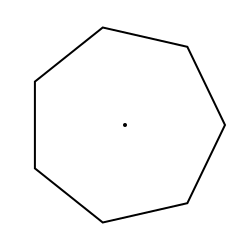

In [7]:
from IPython.display import SVG, display

display(SVG(Polygon(7, 1).to_svg(size=250, padding=25)))


<Axes: title={'center': 'Polygon efficiency by vertex count'}, xlabel='Number of vertices', ylabel='Area : Perimeter ratio'>

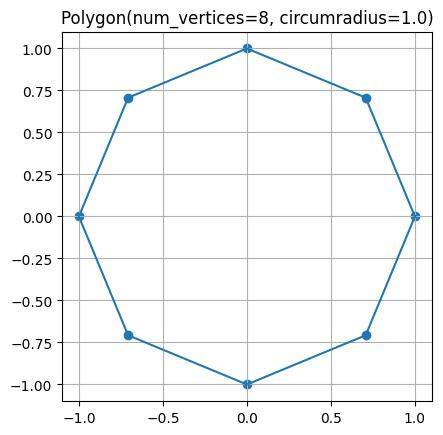

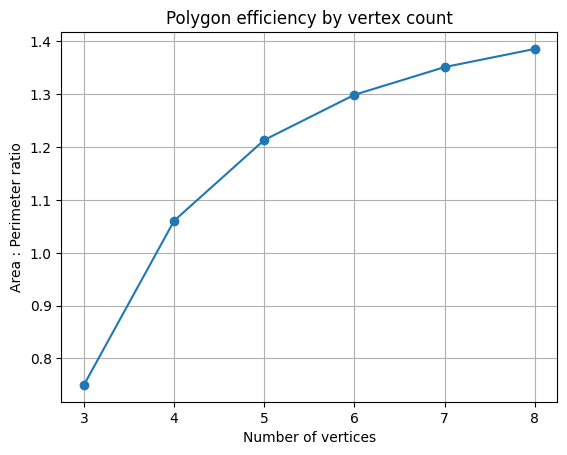

In [9]:
# Optional visual checks
# Uncomment these lines in a notebook environment if Matplotlib is available.

Polygon(8, 1).plot()
polygons.plot_ratios()
